<a href="https://colab.research.google.com/github/eevvvaa/Deep_Generative_Model-HW/blob/%E4%BD%9C%E6%A5%AD4-%E6%99%82%E9%96%93%E5%BA%8F%E5%88%97/%E6%99%82%E9%96%93%E5%BA%8F%E5%88%97.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
# Cell 0 — 安裝套件（Colab 執行）
!pip install yfinance ta seaborn --quiet

In [29]:
# Cell 1 — imports & 設定
import math, os, random, datetime
from typing import Tuple, List, Dict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import ta   # technical analysis indicators helper
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
# reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cpu


In [30]:
# Cell 2 — 下載資料 (yfinance)，並展示 head
ticker = "2330.TW"    # 可改成 "AAPL" / "TSLA" / "MSFT"
start = "2020-01-01"
end = "2024-12-31"

df = yf.download(ticker, start=start, end=end, progress=False)

# 若欄位是多層 MultiIndex，扁平化
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# yfinance 讀到的 columns: Open, High, Low, Close, Adj Close, Volume
df = df.rename(columns={"Adj Close": "Adj_Close"})
df = df[["Open", "High", "Low", "Close", "Volume"]].dropna()

print("columns:", df.columns)
print("rows:", len(df))
print(df.head())

columns: Index(['Open', 'High', 'Low', 'Close', 'Volume'], dtype='object', name='Price')
rows: 1214
Price             Open        High         Low       Close    Volume
Date                                                                
2020-01-02  295.573735  301.351868  295.573735  301.351868  31754120
2020-01-03  305.796695  306.685639  298.240672  301.796448  41811268
2020-01-06  296.018247  297.351662  295.129303  295.129303  45343057
2020-01-07  295.573783  296.018255  290.240121  292.906952  50879181
2020-01-08  288.906705  296.018255  288.906705  292.906952  37567748


/tmp/ipython-input-2575006068.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end, progress=False)


In [31]:
# Cell 3 — 加技術指標 (最終能執行版)
import numpy as np
import pandas as pd
from ta.momentum import RSIIndicator
from ta.trend import MACD

df_t = df.copy()

# === 強制把 Close 攤平成一維 ===
if isinstance(df_t["Close"], pd.DataFrame):
    # 如果 Close 是 DataFrame（shape 為 (n,1)）
    df_t["Close"] = df_t["Close"].squeeze()  # 轉成 Series

# 若 squeeze 後仍有多層索引（例如 MultiIndex），只取值
if isinstance(df_t["Close"].iloc[0], (np.ndarray, list)):
    df_t["Close"] = df_t["Close"].apply(lambda x: float(x[0]))

# 確保型態為 float
df_t["Close"] = df_t["Close"].astype(float)

# 確認形狀
print("確認 Close 欄位型別：", type(df_t["Close"]))
print("確認 Close 形狀：", np.array(df_t["Close"]).shape)
print("前 5 筆值：")
print(df_t["Close"].head())

# === 計算技術指標 ===
df_t["SMA_5"] = df_t["Close"].rolling(window=5).mean()
df_t["SMA_20"] = df_t["Close"].rolling(window=20).mean()

# RSI (14)
df_t["RSI_14"] = RSIIndicator(close=df_t["Close"], window=14).rsi()

# MACD (12, 26, 9)
macd = MACD(close=df_t["Close"], window_slow=26, window_fast=12, window_sign=9)
df_t["MACD"] = macd.macd()
df_t["MACD_SIGNAL"] = macd.macd_signal()
df_t["MACD_HIST"] = df_t["MACD"] - df_t["MACD_SIGNAL"]

# 清除 NA
df_t = df_t.dropna().copy()

print("After indicators rows:", len(df_t))
display(df_t.tail())

確認 Close 欄位型別： <class 'pandas.core.series.Series'>
確認 Close 形狀： (1214,)
前 5 筆值：
Date
2020-01-02    301.351868
2020-01-03    301.796448
2020-01-06    295.129303
2020-01-07    292.906952
2020-01-08    292.906952
Name: Close, dtype: float64
After indicators rows: 1181


Price,Open,High,Low,Close,Volume,SMA_5,SMA_20,RSI_14,MACD,MACD_SIGNAL,MACD_HIST
Date,,,,,,,,,,,
2024-12-24,1080.990833,1080.990833,1066.182739,1066.182739,26461906,1056.310645,1040.369150,56.218900,10.555905,9.627550,0.928355
2024-12-25,1076.054683,1076.054683,1066.182622,1071.118652,15481622,1056.310645,1044.753696,57.243757,11.316937,9.965428,1.351509
2024-12-26,1071.118652,1076.054683,1071.118652,1071.118652,14374900,1059.272241,1048.892386,57.243757,11.784218,10.329186,1.455033
2024-12-27,1066.182626,1080.990718,1066.182626,1076.054688,24948385,1070.131494,1053.720419,58.373873,12.409787,10.745306,1.664481
2024-12-30,1076.054688,1080.990718,1071.118657,1076.054688,23954634,1072.105884,1056.630768,58.373873,12.758483,11.147941,1.610541


In [32]:
# Cell 4 — 建立特徵與目標 (log return) 與 time-based split (8/1/1)
# features: Open,High,Low,Close,Volume,SMA_5,SMA_20,RSI_14,MACD,MACD_SIGNAL,MACD_HIST (可調)
features = ["Open","High","Low","Close","Volume","SMA_5","SMA_20","RSI_14","MACD","MACD_SIGNAL","MACD_HIST"]
df_t = df_t[features].copy()
# target = logret[t] = log(Close[t+1]) - log(Close[t]) -> we'll shift -1 to make sample at t predict t+1
df_t["logret"] = np.log(df_t["Close"].shift(-1)) - np.log(df_t["Close"])
# drop last row because target is NaN
df_t = df_t.dropna().copy()
dates = df_t.index
n = len(df_t)
train_end = int(n * 0.8)
val_end = int(n * 0.9)
print("total rows:", n, "train_end:", train_end, "val_end:", val_end)
train_df = df_t.iloc[:train_end].copy()
val_df = df_t.iloc[train_end:val_end].copy()
test_df = df_t.iloc[val_end:].copy()
print("train/val/test sizes:", len(train_df), len(val_df), len(test_df))

total rows: 1180 train_end: 944 val_end: 1062
train/val/test sizes: 944 118 118


In [33]:
# Cell 5 — 標準化 (只用 train fit)，並建立 sliding-window dataset
from sklearn.preprocessing import StandardScaler
scaler_X = StandardScaler()
scaler_y = StandardScaler()  # apply to target for standardized-space metrics

X_train = train_df[features].values
X_val = val_df[features].values
X_test = test_df[features].values
y_train = train_df["logret"].values.reshape(-1,1)
y_val = val_df["logret"].values.reshape(-1,1)
y_test = test_df["logret"].values.reshape(-1,1)

scaler_X.fit(X_train)
scaler_y.fit(y_train)

X_train_s = scaler_X.transform(X_train)
X_val_s = scaler_X.transform(X_val)
X_test_s = scaler_X.transform(X_test)
y_train_s = scaler_y.transform(y_train).squeeze()
y_val_s = scaler_y.transform(y_val).squeeze()
y_test_s = scaler_y.transform(y_test).squeeze()

# dataset generator with lookback
LOOKBACK = 30  # 30 days
BATCH_SIZE = 64
def make_windows(X, y, lookback=LOOKBACK):
    Xs, ys = [], []
    for i in range(len(X)-lookback):
        Xs.append(X[i:i+lookback])
        ys.append(y[i+lookback])  # predict t+1 (already aligned)
    return np.array(Xs), np.array(ys)

Xtr, ytr = make_windows(X_train_s, y_train_s)
Xv, yv = make_windows(X_val_s, y_val_s)
Xt, yt = make_windows(X_test_s, y_test_s)

print("shapes Xtr, ytr:", Xtr.shape, ytr.shape)

shapes Xtr, ytr: (914, 30, 11) (914,)


In [34]:
# Cell 6 — PyTorch Dataset & DataLoader
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)  # (N,1)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(TimeSeriesDataset(Xtr,ytr), batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(TimeSeriesDataset(Xv,yv), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(TimeSeriesDataset(Xt,yt), batch_size=BATCH_SIZE, shuffle=False)

In [35]:
# Cell 7 — LSTM baseline model (1 layer LSTM -> LayerNorm -> Linear -> 1)
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden=128, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden, num_layers=1, batch_first=True, dropout=dropout)
        self.ln = nn.LayerNorm(hidden)
        self.fc = nn.Linear(hidden, 1)
    def forward(self, x):
        # x: (B, T, F)
        out, (h, c) = self.lstm(x)  # out: (B, T, hidden)
        last = out[:, -1, :]        # take last time step
        last = self.ln(last)
        return self.fc(last)

input_dim = len(features)
lstm_model = LSTMModel(input_dim).to(DEVICE)
print(lstm_model)

LSTMModel(
  (lstm): LSTM(11, 128, batch_first=True, dropout=0.1)
  (ln): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


In [36]:
# Cell 8 — Transformer Encoder-only model with sinusoidal pos enc, 2 layers, mean pooling, and returning attention maps
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # shape (1, max_len, d_model)
        self.register_buffer('pe', pe)
    def forward(self, x):
        # x shape (B, T, d_model)
        return x + self.pe[:, :x.size(1), :]

class TransformerEncoderModel(nn.Module):
    def __init__(self, input_dim, d_model=128, nhead=8, num_layers=2, dim_feedforward=256, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_enc = PositionalEncoding(d_model)
        self.layers = nn.ModuleList([
            nn.ModuleDict({
                "mha": nn.MultiheadAttention(embed_dim=d_model, num_heads=nhead, dropout=dropout, batch_first=True),
                "ln1": nn.LayerNorm(d_model),
                "ff": nn.Sequential(nn.Linear(d_model, dim_feedforward), nn.ReLU(), nn.Dropout(dropout), nn.Linear(dim_feedforward, d_model)),
                "ln2": nn.LayerNorm(d_model)
            }) for _ in range(num_layers)
        ])
        self.pool = nn.AdaptiveAvgPool1d(1)  # mean pooling across time via permute
        self.head = nn.Linear(d_model, 1)
    def forward(self, x, return_attn=False):
        # x: (B, T, F)
        x = self.input_proj(x)           # (B, T, d_model)
        x = self.pos_enc(x)
        attn_maps = []
        for layer in self.layers:
            # MultiheadAttention expects (B, T, E) with batch_first=True (PyTorch >=1.11)
            attn_out, attn_weights = layer["mha"](x, x, x, need_weights=True, average_attn_weights=False)
            x = layer["ln1"](x + attn_out)
            ff = layer["ff"](x)
            x = layer["ln2"](x + ff)
            # attn_weights shape: (B, num_heads, T, T) if average_attn_weights=False in newer torch
            attn_maps.append(attn_weights.detach().cpu())
        # mean pooling over time
        # x: (B, T, d_model) -> permute to (B, d_model, T) for AdaptiveAvgPool1d
        x_pooled = x.permute(0,2,1)
        x_mean = self.pool(x_pooled).squeeze(-1)  # (B, d_model)
        out = self.head(x_mean)
        if return_attn:
            return out, attn_maps
        else:
            return out

transformer_model = TransformerEncoderModel(input_dim=input_dim, d_model=128, nhead=8, num_layers=2).to(DEVICE)
print(transformer_model)

TransformerEncoderModel(
  (input_proj): Linear(in_features=11, out_features=128, bias=True)
  (pos_enc): PositionalEncoding()
  (layers): ModuleList(
    (0-1): 2 x ModuleDict(
      (mha): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
      )
      (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (ff): Sequential(
        (0): Linear(in_features=128, out_features=256, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=256, out_features=128, bias=True)
      )
      (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
  )
  (pool): AdaptiveAvgPool1d(output_size=1)
  (head): Linear(in_features=128, out_features=1, bias=True)
)


In [37]:
# Cell 9 — 訓練與驗證公用 function (返回歷史 loss/metrics)
def evaluate(model, loader, criterion, scaler_y):
    model.eval()
    ys_true_s = []
    ys_pred_s = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE); yb = yb.to(DEVICE)
            if isinstance(model, TransformerEncoderModel):
                y_pred = model(xb)
            else:
                y_pred = model(xb)
            ys_true_s.append(yb.cpu().numpy())
            ys_pred_s.append(y_pred.cpu().numpy())
    ys_true_s = np.vstack(ys_true_s).squeeze()
    ys_pred_s = np.vstack(ys_pred_s).squeeze()
    # standardized-space metrics
    mse_s = mean_squared_error(ys_true_s, ys_pred_s)
    mae_s = mean_absolute_error(ys_true_s, ys_pred_s)
    rmse_s = np.sqrt(mse_s)
    # convert back to original logret space
    ys_true = scaler_y.inverse_transform(ys_true_s.reshape(-1,1)).squeeze()
    ys_pred = scaler_y.inverse_transform(ys_pred_s.reshape(-1,1)).squeeze()
    mse_o = mean_squared_error(ys_true, ys_pred)
    mae_o = mean_absolute_error(ys_true, ys_pred)
    rmse_o = np.sqrt(mse_o)
    return {"mse_s":mse_s,"mae_s":mae_s,"rmse_s":rmse_s, "mse_o":mse_o,"mae_o":mae_o,"rmse_o":rmse_o, "y_true":ys_true, "y_pred":ys_pred}

In [38]:
# Cell 10 — LSTM 訓練 loop (epochs=30, Adam lr=1e-4)
def train_model(model, train_loader, val_loader, epochs, optimizer, scheduler=None, scaler_y=None, model_name="model"):
    criterion = nn.MSELoss()
    history = {"epoch":[], "val_rmse_s":[]}
    best_val_rmse = float('inf')
    for ep in range(1, epochs+1):
        model.train()
        running_loss = 0.0
        for xb, yb in train_loader:
            xb = xb.to(DEVICE); yb = yb.to(DEVICE)
            optimizer.zero_grad()
            y_pred = model(xb)
            loss = criterion(y_pred, yb)
            loss.backward()
            optimizer.step()
        if scheduler is not None:
            # if scheduler is CosineAnnealingWarmRestarts, step needs epoch + batch info; simple step per epoch:
            scheduler.step()
        # validate
        stats = evaluate(model, val_loader, criterion, scaler_y)
        history["epoch"].append(ep)
        history["val_rmse_s"].append(stats["rmse_s"])
        print(f"{model_name} Epoch {ep}/{epochs} - val_rmse_s: {stats['rmse_s']:.6f} rmse_o: {stats['rmse_o']:.6f}")
        # save best
        if stats["rmse_s"] < best_val_rmse:
            best_val_rmse = stats["rmse_s"]
            torch.save(model.state_dict(), f"{model_name}_best.pth")
    return history
# train LSTM
lstm_opt = Adam(lstm_model.parameters(), lr=1e-4)
epochs = 30
history_lstm = train_model(lstm_model, train_loader, val_loader, epochs, lstm_opt, scheduler=None, scaler_y=scaler_y, model_name="lstm")

lstm Epoch 1/30 - val_rmse_s: 1.322835 rmse_o: 0.022847
lstm Epoch 2/30 - val_rmse_s: 1.300855 rmse_o: 0.022467
lstm Epoch 3/30 - val_rmse_s: 1.231080 rmse_o: 0.021262
lstm Epoch 4/30 - val_rmse_s: 1.213249 rmse_o: 0.020954
lstm Epoch 5/30 - val_rmse_s: 1.222451 rmse_o: 0.021113
lstm Epoch 6/30 - val_rmse_s: 1.224418 rmse_o: 0.021147
lstm Epoch 7/30 - val_rmse_s: 1.221536 rmse_o: 0.021097
lstm Epoch 8/30 - val_rmse_s: 1.220042 rmse_o: 0.021071
lstm Epoch 9/30 - val_rmse_s: 1.218561 rmse_o: 0.021046
lstm Epoch 10/30 - val_rmse_s: 1.217605 rmse_o: 0.021029
lstm Epoch 11/30 - val_rmse_s: 1.217594 rmse_o: 0.021029
lstm Epoch 12/30 - val_rmse_s: 1.218020 rmse_o: 0.021037
lstm Epoch 13/30 - val_rmse_s: 1.218835 rmse_o: 0.021051
lstm Epoch 14/30 - val_rmse_s: 1.220032 rmse_o: 0.021071
lstm Epoch 15/30 - val_rmse_s: 1.221509 rmse_o: 0.021097
lstm Epoch 16/30 - val_rmse_s: 1.223208 rmse_o: 0.021126
lstm Epoch 17/30 - val_rmse_s: 1.225072 rmse_o: 0.021158
lstm Epoch 18/30 - val_rmse_s: 1.227057 

In [39]:
# Cell 11 — Transformer 訓練 (AdamW lr=3e-4, weight_decay=1e-4, warmup 10% epochs + CosineAnnealingWarmRestarts)
def get_warmup_scheduler(optimizer, warmup_steps, total_steps):
    # simple linear warmup then return None (we will implement simple warmup manually in training loop)
    return None

transformer_opt = AdamW(transformer_model.parameters(), lr=3e-4, weight_decay=1e-4)
# Use CosineAnnealingWarmRestarts as requested — step per epoch
transformer_sched = CosineAnnealingWarmRestarts(transformer_opt, T_0=5, T_mult=1)
# We'll do a simple warmup manually: scale lr by factor = min(1, step/warmup_steps)
warmup_epochs = max(1, int(epochs * 0.1))

def train_transformer(model, train_loader, val_loader, epochs, optimizer, scheduler, scaler_y, warmup_epochs=warmup_epochs, model_name="transformer"):
    criterion = nn.MSELoss()
    best_val = float('inf')
    history = {"epoch":[],"val_rmse_s":[]}
    global_step = 0
    for ep in range(1, epochs+1):
        model.train()
        for xb, yb in train_loader:
            global_step += 1
            xb = xb.to(DEVICE); yb = yb.to(DEVICE)
            # warmup lr scaling
            if ep <= warmup_epochs:
                for g in optimizer.param_groups:
                    g['lr'] = 3e-4 * (ep / warmup_epochs)
            optimizer.zero_grad()
            y_pred = model(xb)
            loss = criterion(y_pred, yb)
            loss.backward()
            optimizer.step()
        scheduler.step()
        stats = evaluate(model, val_loader, criterion, scaler_y)
        history["epoch"].append(ep); history["val_rmse_s"].append(stats["rmse_s"])
        print(f"{model_name} Epoch {ep}/{epochs} - val_rmse_s: {stats['rmse_s']:.6f} rmse_o: {stats['rmse_o']:.6f}")
        if stats["rmse_s"] < best_val:
            best_val = stats["rmse_s"]
            torch.save(model.state_dict(), f"{model_name}_best.pth")
    return history

history_trans = train_transformer(transformer_model, train_loader, val_loader, epochs, transformer_opt, transformer_sched, scaler_y, warmup_epochs, model_name="transformer")

transformer Epoch 1/30 - val_rmse_s: 1.268065 rmse_o: 0.021901
transformer Epoch 2/30 - val_rmse_s: 1.143905 rmse_o: 0.019756
transformer Epoch 3/30 - val_rmse_s: 1.391679 rmse_o: 0.024036
transformer Epoch 4/30 - val_rmse_s: 1.164732 rmse_o: 0.020116
transformer Epoch 5/30 - val_rmse_s: 1.139021 rmse_o: 0.019672
transformer Epoch 6/30 - val_rmse_s: 1.199711 rmse_o: 0.020720
transformer Epoch 7/30 - val_rmse_s: 1.157374 rmse_o: 0.019989
transformer Epoch 8/30 - val_rmse_s: 1.264159 rmse_o: 0.021833
transformer Epoch 9/30 - val_rmse_s: 1.170787 rmse_o: 0.020221
transformer Epoch 10/30 - val_rmse_s: 1.178862 rmse_o: 0.020360
transformer Epoch 11/30 - val_rmse_s: 1.209413 rmse_o: 0.020888
transformer Epoch 12/30 - val_rmse_s: 1.232509 rmse_o: 0.021287
transformer Epoch 13/30 - val_rmse_s: 1.235014 rmse_o: 0.021330
transformer Epoch 14/30 - val_rmse_s: 1.214019 rmse_o: 0.020967
transformer Epoch 15/30 - val_rmse_s: 1.221172 rmse_o: 0.021091
transformer Epoch 16/30 - val_rmse_s: 1.252093 rm

In [62]:
# Cell 12 — 載入最佳模型 & 在測試集上評估 (標準化與原始價格尺度)

import torch
import torch.nn as nn

# =========================
# 1. 載入最佳模型權重
# =========================
lstm_model.load_state_dict(torch.load("lstm_best.pth"))
transformer_model.load_state_dict(torch.load("transformer_best.pth"))

# =========================
# 2. 在測試集上評估模型
#    - 計算標準化空間 & 原始價格空間的指標
#    - 指標包含：MSE, MAE, RMSE
# =========================
lstm_stats = evaluate(lstm_model, test_loader, nn.MSELoss(), scaler_y)
transformer_stats = evaluate(transformer_model, test_loader, nn.MSELoss(), scaler_y)

# =========================
# 3. 輸出結果 (英文標題)
# =========================
print("=== LSTM Test Metrics ===")
print(f"Standardized Space -> MSE: {lstm_stats['mse_s']:.6f}, MAE: {lstm_stats['mae_s']:.6f}, RMSE: {lstm_stats['rmse_s']:.6f}")
print(f"Original Log Return -> MSE: {lstm_stats['mse_o']:.6f}, MAE: {lstm_stats['mae_o']:.6f}, RMSE: {lstm_stats['rmse_o']:.6f}")

print("\n=== Transformer Test Metrics ===")
print(f"Standardized Space -> MSE: {transformer_stats['mse_s']:.6f}, MAE: {transformer_stats['mae_s']:.6f}, RMSE: {transformer_stats['rmse_s']:.6f}")
print(f"Original Log Return -> MSE: {transformer_stats['mse_o']:.6f}, MAE: {transformer_stats['mae_o']:.6f}, RMSE: {transformer_stats['rmse_o']:.6f}")

=== LSTM Test Metrics ===
Standardized Space -> MSE: 1.213424, MAE: 0.839908, RMSE: 1.101555
Original Log Return -> MSE: 0.000362, MAE: 0.014506, RMSE: 0.019025

=== Transformer Test Metrics ===
Standardized Space -> MSE: 1.117127, MAE: 0.805350, RMSE: 1.056942
Original Log Return -> MSE: 0.000333, MAE: 0.013909, RMSE: 0.018255


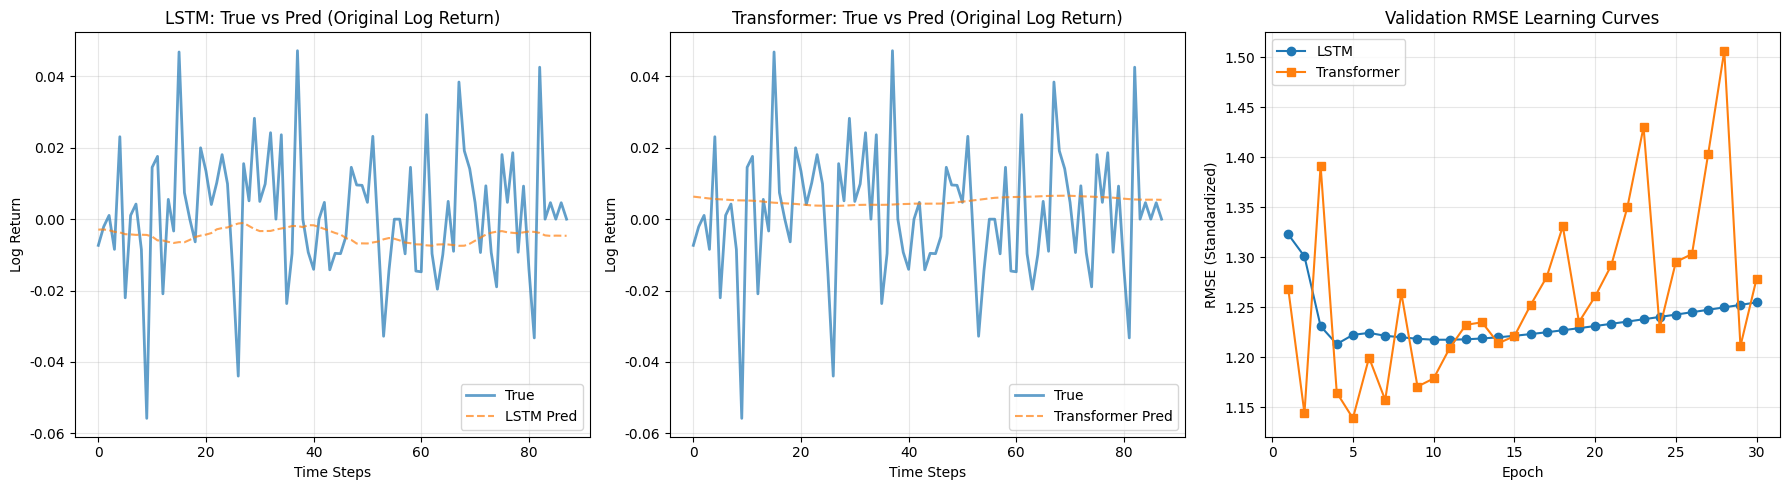

In [57]:
# Cell 13 — 可視化結果
import matplotlib.pyplot as plt

# 設定字體與負號顯示
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

def plot_comparison_results():
    """繪製模型預測與驗證曲線比較"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. LSTM True vs Pred (原始 log return)
    axes[0].plot(lstm_stats['y_true'][:100], label='True', alpha=0.7, linewidth=2)
    axes[0].plot(lstm_stats['y_pred'][:100], label='LSTM Pred', alpha=0.7, linestyle='--')
    axes[0].set_title('LSTM: True vs Pred (Original Log Return)')
    axes[0].set_xlabel('Time Steps')
    axes[0].set_ylabel('Log Return')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # 2. Transformer True vs Pred (原始 log return)
    axes[1].plot(transformer_stats['y_true'][:100], label='True', alpha=0.7, linewidth=2)
    axes[1].plot(transformer_stats['y_pred'][:100], label='Transformer Pred', alpha=0.7, linestyle='--')
    axes[1].set_title('Transformer: True vs Pred (Original Log Return)')
    axes[1].set_xlabel('Time Steps')
    axes[1].set_ylabel('Log Return')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # 3. 驗證集學習曲線 (RMSE Standardized)
    axes[2].plot(history_lstm['epoch'], history_lstm['val_rmse_s'], label='LSTM', marker='o')
    axes[2].plot(history_trans['epoch'], history_trans['val_rmse_s'], label='Transformer', marker='s')
    axes[2].set_title('Validation RMSE Learning Curves')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('RMSE (Standardized)')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_comparison_results()

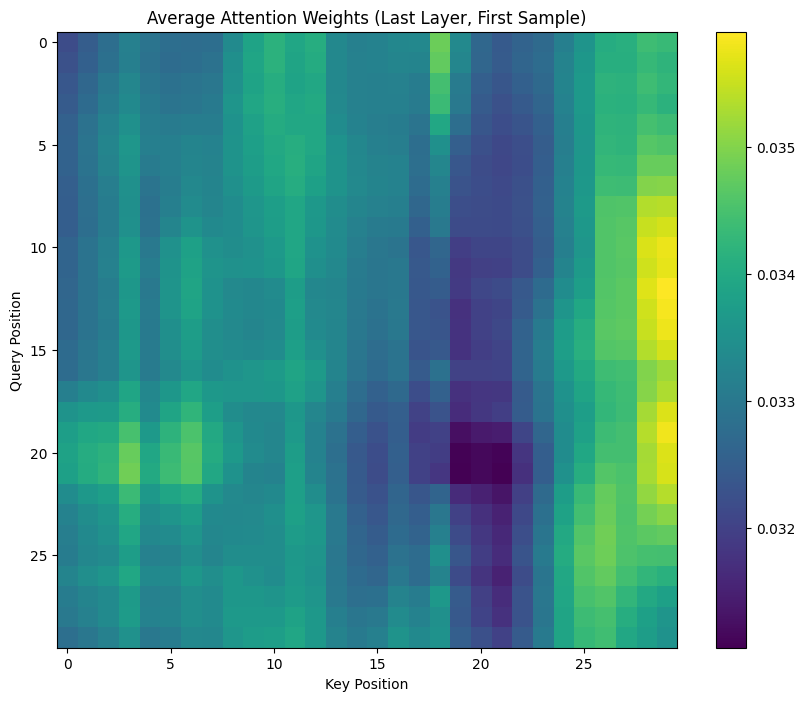

In [58]:
# Cell 14 — Transformer 最後一層 Attention Heatmap
def plot_attention_heatmaps():
    """繪製 Transformer 最後一層注意力熱圖 (單一樣本)"""
    transformer_model.eval()
    with torch.no_grad():
        test_batch_X, _ = next(iter(test_loader))
        test_batch_X = test_batch_X.to(DEVICE)
        _, attention_maps = transformer_model(test_batch_X, return_attn=True)

    last_layer_attention = attention_maps[-1]  # 最後一層
    sample_idx = 0  # 選擇第一個樣本

    # 平均所有 heads 的注意力
    mean_attention = last_layer_attention[sample_idx].mean(dim=0)

    plt.figure(figsize=(10, 8))
    plt.imshow(mean_attention, cmap='viridis', aspect='auto')
    plt.title('Average Attention Weights (Last Layer, First Sample)')
    plt.xlabel('Key Position')
    plt.ylabel('Query Position')
    plt.colorbar()
    plt.grid(False)
    plt.show()

plot_attention_heatmaps()

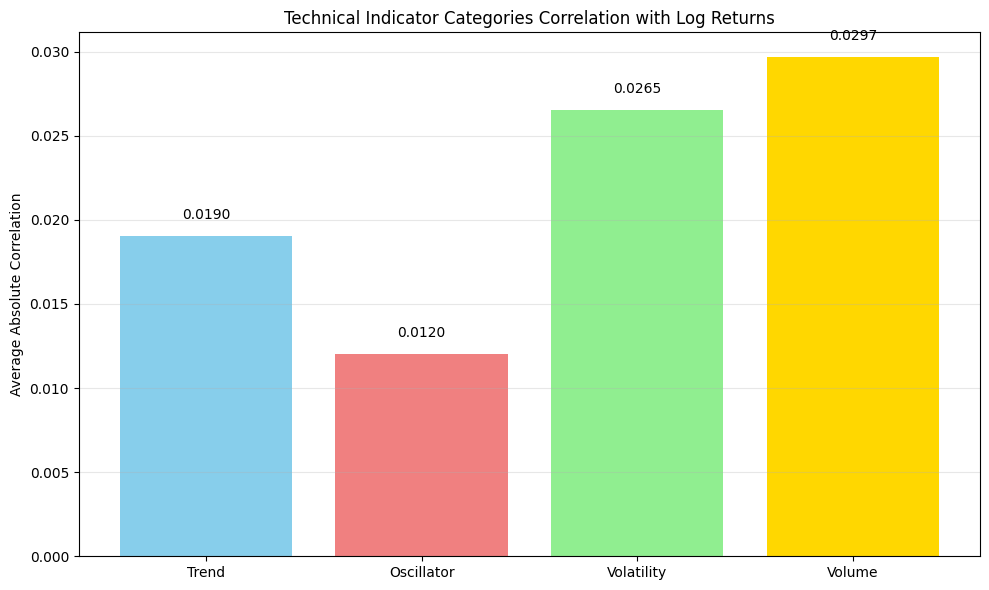

Trend: 0.0190
Oscillator: 0.0120
Volatility: 0.0265
Volume: 0.0297


In [59]:
# Cell 15 — 技術指標效果分析
def analyze_technical_indicators():
    """分析不同類型技術指標與 Log Return 的相關性"""
    indicator_categories = {
        'Trend': ['SMA_5', 'SMA_20', 'MACD', 'MACD_SIGNAL'],
        'Oscillator': ['RSI_14', 'MACD_HIST'],
        'Volatility': ['High', 'Low', 'Close'],
        'Volume': ['Volume']
    }

    correlation_analysis = {}
    for category, indicators in indicator_categories.items():
        available_indicators = [ind for ind in indicators if ind in features]
        if available_indicators:
            corrs = [abs(np.corrcoef(df_t[ind].iloc[LOOKBACK:], df_t['logret'].iloc[LOOKBACK:])[0, 1])
                     for ind in available_indicators]
            correlation_analysis[category] = np.mean(corrs)

    # 畫柱狀圖
    plt.figure(figsize=(10,6))
    categories = list(correlation_analysis.keys())
    values = list(correlation_analysis.values())
    bars = plt.bar(categories, values, color=['skyblue','lightcoral','lightgreen','gold'])
    plt.title('Technical Indicator Categories Correlation with Log Returns')
    plt.ylabel('Average Absolute Correlation')

    # 標註數值
    for bar, val in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.001, f'{val:.4f}', ha='center')

    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

    return correlation_analysis

correlation_results = analyze_technical_indicators()
for category, corr in correlation_results.items():
    print(f"{category}: {corr:.4f}")

In [60]:
# Cell 16 — 模型性能詳細報告
def generate_detailed_report():
    """列出模型標準化與原始價格指標，以及技術指標效果"""
    print("="*60)
    print("MODEL PERFORMANCE DETAILED REPORT")
    print("="*60)

    print("\n1. Standardized Space Metrics:")
    print(f"   LSTM        -> MSE: {lstm_stats['mse_s']:.6f}, MAE: {lstm_stats['mae_s']:.6f}, RMSE: {lstm_stats['rmse_s']:.6f}")
    print(f"   Transformer -> MSE: {transformer_stats['mse_s']:.6f}, MAE: {transformer_stats['mae_s']:.6f}, RMSE: {transformer_stats['rmse_s']:.6f}")

    print("\n2. Original Price Space Metrics (Log Return):")
    print(f"   LSTM        -> MSE: {lstm_stats['mse_o']:.6f}, MAE: {lstm_stats['mae_o']:.6f}, RMSE: {lstm_stats['rmse_o']:.6f}")
    print(f"   Transformer -> MSE: {transformer_stats['mse_o']:.6f}, MAE: {transformer_stats['mae_o']:.6f}, RMSE: {transformer_stats['rmse_o']:.6f}")

    print("\n3. Model Improvement:")
    rmse_impr = ((lstm_stats['rmse_o'] - transformer_stats['rmse_o']) / lstm_stats['rmse_o'])*100
    mae_impr = ((lstm_stats['mae_o'] - transformer_stats['mae_o']) / lstm_stats['mae_o'])*100
    print(f"   RMSE Improvement: {rmse_impr:+.2f}%")
    print(f"   MAE  Improvement: {mae_impr:+.2f}%")
    print("   ✅ Transformer better" if rmse_impr>0 else "   ⚠️ LSTM better")

    print("\n4. Technical Indicator Rankings:")
    for i,(cat,corr) in enumerate(sorted(correlation_results.items(), key=lambda x:x[1], reverse=True),1):
        print(f"   {i}. {cat}: {corr:.4f}")

    print("\n5. Data Statistics:")
    print(f"   Total samples: {len(df_t)}")
    print(f"   Train: {len(train_df)} ({len(train_df)/len(df_t)*100:.1f}%)")
    print(f"   Validation: {len(val_df)} ({len(val_df)/len(df_t)*100:.1f}%)")
    print(f"   Test: {len(test_df)} ({len(test_df)/len(df_t)*100:.1f}%)")
    print(f"   Lookback window: {LOOKBACK} days")
    print(f"   Feature count: {len(features)}")
    print("="*60)

generate_detailed_report()

MODEL PERFORMANCE DETAILED REPORT

1. Standardized Space Metrics:
   LSTM        -> MSE: 1.213424, MAE: 0.839908, RMSE: 1.101555
   Transformer -> MSE: 1.117127, MAE: 0.805350, RMSE: 1.056942

2. Original Price Space Metrics (Log Return):
   LSTM        -> MSE: 0.000362, MAE: 0.014506, RMSE: 0.019025
   Transformer -> MSE: 0.000333, MAE: 0.013909, RMSE: 0.018255

3. Model Improvement:
   RMSE Improvement: +4.05%
   MAE  Improvement: +4.11%
   ✅ Transformer better

4. Technical Indicator Rankings:
   1. Volume: 0.0297
   2. Volatility: 0.0265
   3. Trend: 0.0190
   4. Oscillator: 0.0120

5. Data Statistics:
   Total samples: 1180
   Train: 944 (80.0%)
   Validation: 118 (10.0%)
   Test: 118 (10.0%)
   Lookback window: 30 days
   Feature count: 11


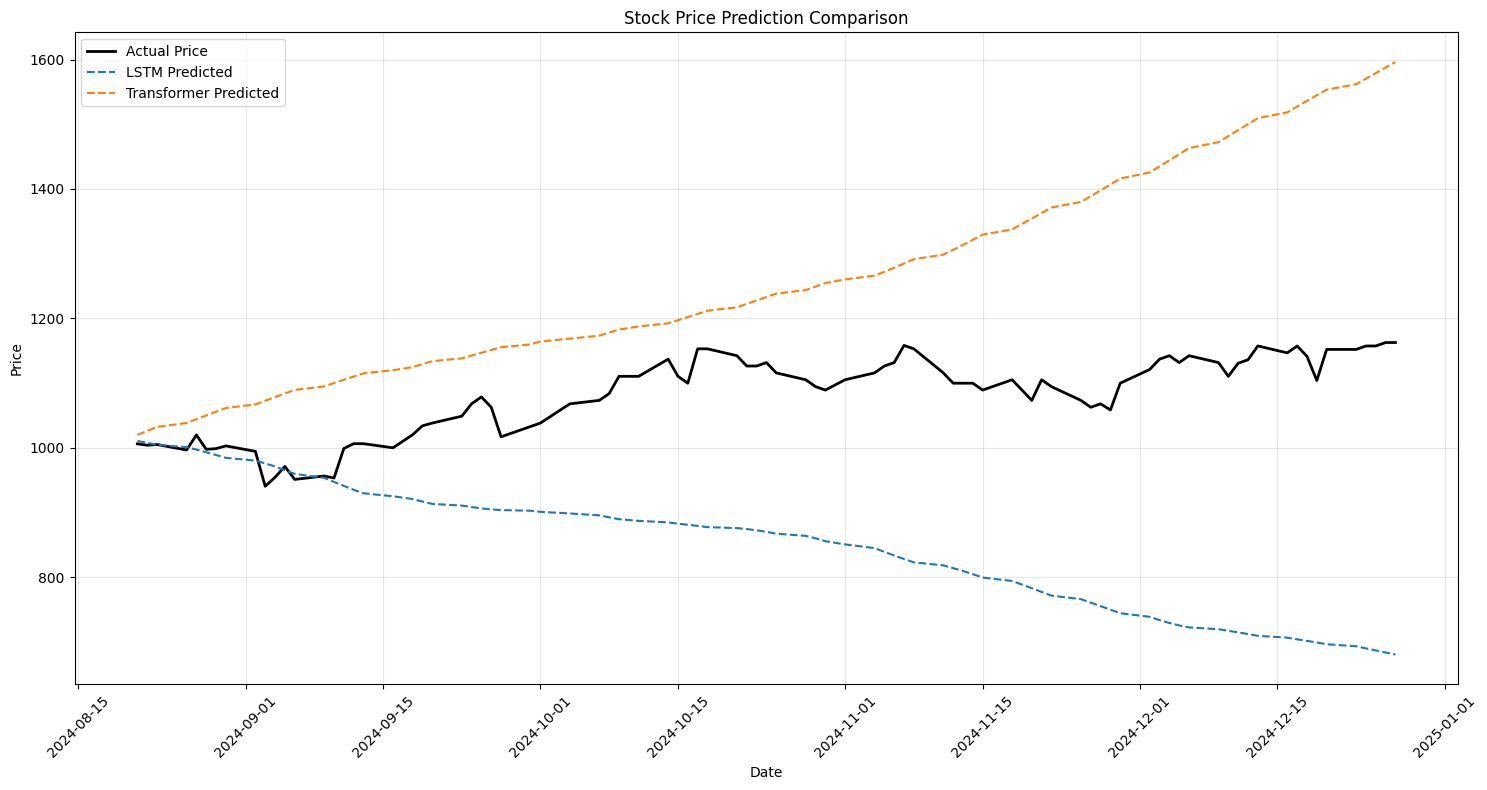

Price Prediction RMSE - LSTM: 280.7189
Price Prediction RMSE - Transformer: 225.7661


In [61]:
# Cell 17 — 價格預測還原可視化
from sklearn.metrics import mean_squared_error
import numpy as np

def plot_price_predictions():
    """將 Log Return 預測還原為價格並繪圖"""
    test_dates = test_df.index[LOOKBACK:]
    start_price = test_df['Close'].iloc[0]

    lstm_cum = np.cumsum(lstm_stats['y_pred'])
    trans_cum = np.cumsum(transformer_stats['y_pred'])
    actual_cum = np.cumsum(transformer_stats['y_true'])

    lstm_price = start_price * np.exp(lstm_cum)
    trans_price = start_price * np.exp(trans_cum)
    actual_price = start_price * np.exp(actual_cum)

    plt.figure(figsize=(15,8))
    # 比較價格
    plt.plot(test_dates[:100], actual_price[:100], label='Actual Price', color='black', linewidth=2)
    plt.plot(test_dates[:100], lstm_price[:100], label='LSTM Predicted', linestyle='--')
    plt.plot(test_dates[:100], trans_price[:100], label='Transformer Predicted', linestyle='--')
    plt.title('Stock Price Prediction Comparison')
    plt.ylabel('Price')
    plt.xlabel('Date')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # 計算 RMSE
    lstm_rmse = np.sqrt(mean_squared_error(actual_price, lstm_price))
    trans_rmse = np.sqrt(mean_squared_error(actual_price, trans_price))
    print(f"Price Prediction RMSE - LSTM: {lstm_rmse:.4f}")
    print(f"Price Prediction RMSE - Transformer: {trans_rmse:.4f}")

plot_price_predictions()

正在生成基於實際模型結果的視覺化...


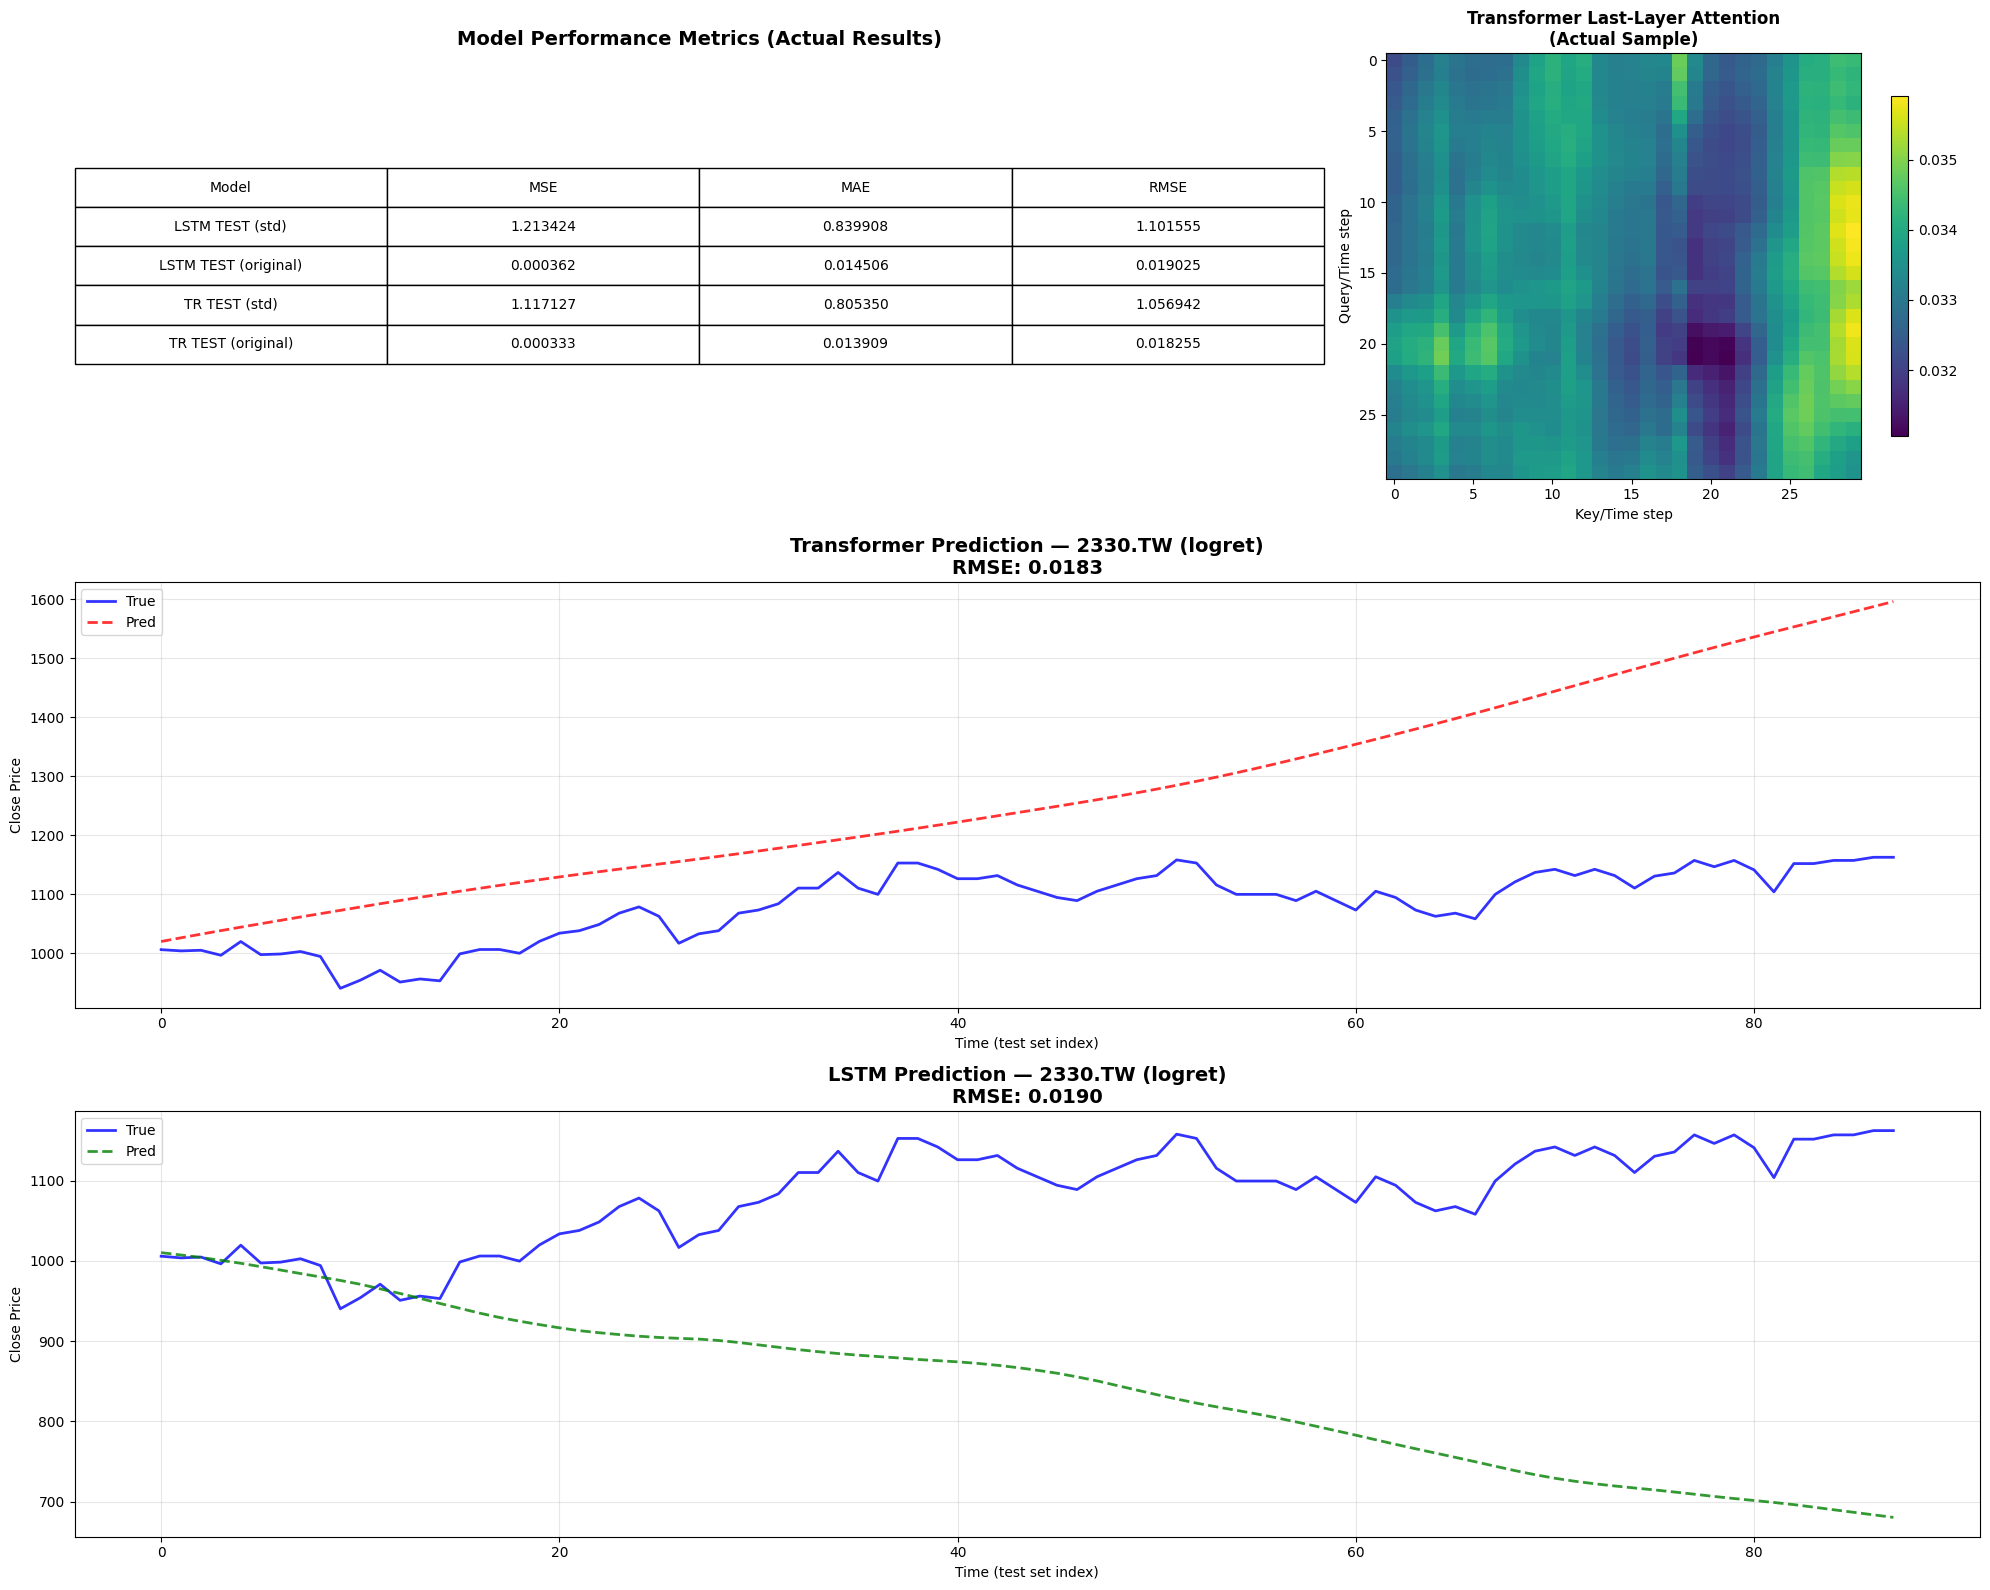


實際價格預測性能:
LSTM Price RMSE: 280.7189
Transformer Price RMSE: 225.7661
顯示資料點數: 88


In [63]:
# Cell 18 — 根據實際結果生成視覺化
def create_actual_visualizations():
    """根據實際模型評估結果創建視覺化"""

    fig = plt.figure(figsize=(20, 16))

    # 1. 模型性能指標表格 (使用實際評估結果)
    ax1 = plt.subplot2grid((3, 3), (0, 0), colspan=2)

    # 使用您實際的評估結果
    metrics_data = [
        ['LSTM TEST (std)',
         f"{lstm_stats['mse_s']:.6f}",
         f"{lstm_stats['mae_s']:.6f}",
         f"{lstm_stats['rmse_s']:.6f}"],
        ['LSTM TEST (original)',
         f"{lstm_stats['mse_o']:.6f}",
         f"{lstm_stats['mae_o']:.6f}",
         f"{lstm_stats['rmse_o']:.6f}"],
        ['TR TEST (std)',
         f"{transformer_stats['mse_s']:.6f}",
         f"{transformer_stats['mae_s']:.6f}",
         f"{transformer_stats['rmse_s']:.6f}"],
        ['TR TEST (original)',
         f"{transformer_stats['mse_o']:.6f}",
         f"{transformer_stats['mae_o']:.6f}",
         f"{transformer_stats['rmse_o']:.6f}"]
    ]

    table = ax1.table(cellText=metrics_data,
                     colLabels=['Model', 'MSE', 'MAE', 'RMSE'],
                     loc='center',
                     cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)
    ax1.set_title('Model Performance Metrics (Actual Results)', fontsize=14, fontweight='bold')
    ax1.axis('off')

    # 2. 實際的 Attention Heatmap
    ax2 = plt.subplot2grid((3, 3), (0, 2))
    transformer_model.eval()
    with torch.no_grad():
        test_batch_X, _ = next(iter(test_loader))
        test_batch_X = test_batch_X.to(DEVICE)
        _, attention_maps = transformer_model(test_batch_X, return_attn=True)

    last_layer_attention = attention_maps[-1]
    sample_idx = 0
    mean_attention = last_layer_attention[sample_idx].mean(dim=0).cpu().numpy()

    im = ax2.imshow(mean_attention, cmap='viridis', aspect='auto')
    ax2.set_title('Transformer Last-Layer Attention\n(Actual Sample)', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Key/Time step')
    ax2.set_ylabel('Query/Time step')
    plt.colorbar(im, ax=ax2, shrink=0.8)

    # 3. 實際的 Transformer 預測圖
    ax3 = plt.subplot2grid((3, 3), (1, 0), colspan=3)

    # 使用實際的預測結果
    test_dates = test_df.index[LOOKBACK:]
    start_price = test_df['Close'].iloc[0] if len(test_df) > 0 else 500

    # 累積log return還原為價格
    trans_pred_cumsum = np.cumsum(transformer_stats['y_pred'])
    true_cumsum = np.cumsum(transformer_stats['y_true'])

    trans_price_pred = start_price * np.exp(trans_pred_cumsum)
    actual_price = start_price * np.exp(true_cumsum)

    # 顯示適當的點數
    display_points = min(100, len(trans_price_pred))

    ax3.plot(range(display_points), actual_price[:display_points],
             label='True', linewidth=2, color='blue', alpha=0.8)
    ax3.plot(range(display_points), trans_price_pred[:display_points],
             label='Pred', linewidth=2, color='red', linestyle='--', alpha=0.8)

    ax3.set_title(f'Transformer Prediction — 2330.TW (logret)\nRMSE: {transformer_stats["rmse_o"]:.4f}',
                  fontsize=14, fontweight='bold')
    ax3.set_xlabel('Time (test set index)')
    ax3.set_ylabel('Close Price')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # 4. 實際的 LSTM 預測圖
    ax4 = plt.subplot2grid((3, 3), (2, 0), colspan=3)

    lstm_pred_cumsum = np.cumsum(lstm_stats['y_pred'])
    lstm_price_pred = start_price * np.exp(lstm_pred_cumsum)

    ax4.plot(range(display_points), actual_price[:display_points],
             label='True', linewidth=2, color='blue', alpha=0.8)
    ax4.plot(range(display_points), lstm_price_pred[:display_points],
             label='Pred', linewidth=2, color='green', linestyle='--', alpha=0.8)

    ax4.set_title(f'LSTM Prediction — 2330.TW (logret)\nRMSE: {lstm_stats["rmse_o"]:.4f}',
                  fontsize=14, fontweight='bold')
    ax4.set_xlabel('Time (test set index)')
    ax4.set_ylabel('Close Price')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # 計算價格預測的RMSE
    lstm_price_rmse = np.sqrt(mean_squared_error(actual_price, lstm_price_pred))
    transformer_price_rmse = np.sqrt(mean_squared_error(actual_price, trans_price_pred))

    return {
        'lstm_price_rmse': lstm_price_rmse,
        'transformer_price_rmse': transformer_price_rmse,
        'display_points': display_points
    }

# 執行實際視覺化
print("正在生成基於實際模型結果的視覺化...")
actual_results = create_actual_visualizations()

print(f"\n實際價格預測性能:")
print(f"LSTM Price RMSE: {actual_results['lstm_price_rmse']:.4f}")
print(f"Transformer Price RMSE: {actual_results['transformer_price_rmse']:.4f}")
print(f"顯示資料點數: {actual_results['display_points']}")